# 04. How wind and solar shape electricity prices in Portugal

In [1]:
# Import the libraries and open the database
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

connection = sqlite3.connect("../data/electricity.db")

In [2]:
# Join prices and production for each date and hour
query = """
SELECT p.date, p.hour, p.price_pt,
       r.consumption, r.solar, r.wind, r.hydro, r.natural_gas
FROM prices AS p
JOIN production AS r
  ON p.date = r.date AND p.hour = r.hour
"""
df = pd.read_sql(query, connection)

# Year and share of consumption covered by wind and solar (%)
df["year"] = df["date"].str[:4].astype(int)
df["renewable_share"] = (df["wind"] + df["solar"]) / df["consumption"] * 100
print(len(df), "hours with both price and production")

67928 hours with both price and production


## 1. More wind and solar, lower prices (the merit order effect)

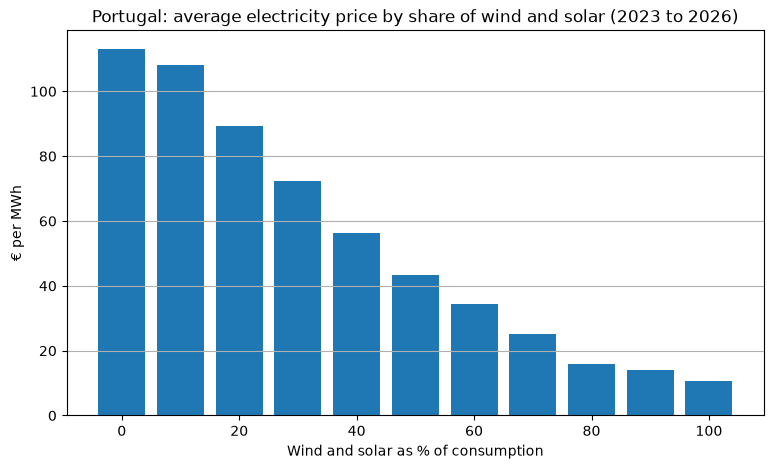

In [3]:
# Average price by share of consumption covered by wind and solar, in groups of 10 points (2023 onwards)
df["share_group"] = ((df["renewable_share"] // 10) * 10).clip(upper=100)
by_share = df[df["year"] >= 2023].groupby("share_group")["price_pt"].mean()

plt.figure(figsize=(9, 5))
plt.bar(by_share.index, by_share.values, width=8)
plt.title("Portugal: average electricity price by share of wind and solar (2023 to 2026)")
plt.xlabel("Wind and solar as % of consumption")
plt.ylabel("€ per MWh")
plt.grid(True, axis="y")
plt.savefig("../figures/price_by_renewable_share.png")
plt.show()

## 2. The duck curve: prices by hour of the day

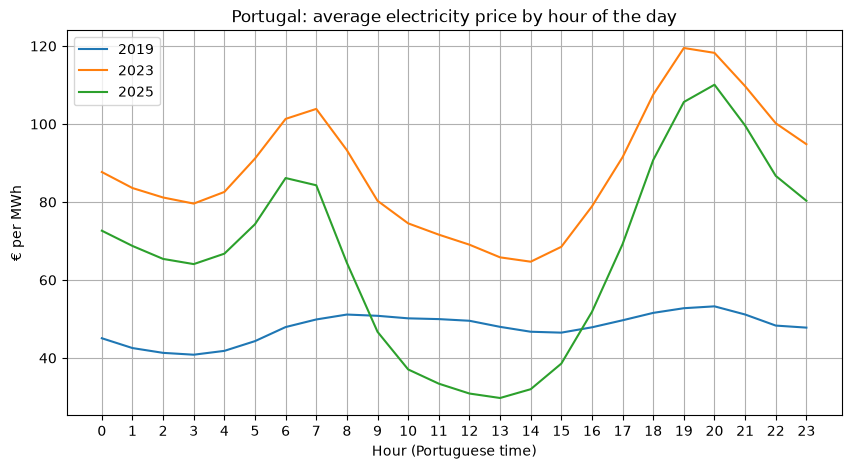

In [4]:
# Average price by hour of the day in 2019, 2023 and 2025
plt.figure(figsize=(10, 5))
for year in [2019, 2023, 2025]:
    by_hour = df[df["year"] == year].groupby("hour")["price_pt"].mean()
    plt.plot(by_hour.index, by_hour.values, label=str(year))
plt.title("Portugal: average electricity price by hour of the day")
plt.xlabel("Hour (Portuguese time)")
plt.ylabel("€ per MWh")
plt.xticks(range(0, 24))
plt.legend()
plt.grid(True)
plt.savefig("../figures/duck_curve.png")
plt.show()

## 3. Solar cannibalisation: how much is solar energy worth?
The solar capture price is the average price weighted by solar production. The capture rate compares it with the simple average price.

In [5]:
# Solar capture price by year: total (price x solar) divided by total solar
df["price_x_solar"] = df["price_pt"] * df["solar"]
yearly = df.groupby("year")[["price_x_solar", "solar"]].sum()
yearly["solar_capture_price"] = yearly["price_x_solar"] / yearly["solar"]

# Compare with the simple average price
yearly["avg_price"] = df.groupby("year")["price_pt"].mean()
yearly["capture_rate"] = yearly["solar_capture_price"] / yearly["avg_price"] * 100
yearly[["avg_price", "solar_capture_price", "capture_rate"]].round(1)

,avg_price,solar_capture_price,capture_rate
year,,,
2019,47.9,48.8,101.9
2020,34.0,33.2,97.7
2021,112.0,107.5,96.0
2022,167.9,151.0,89.9
2023,88.3,73.0,82.7
2024,63.5,42.7,67.3
2025,66.2,35.3,53.4
2026,74.4,37.4,50.2


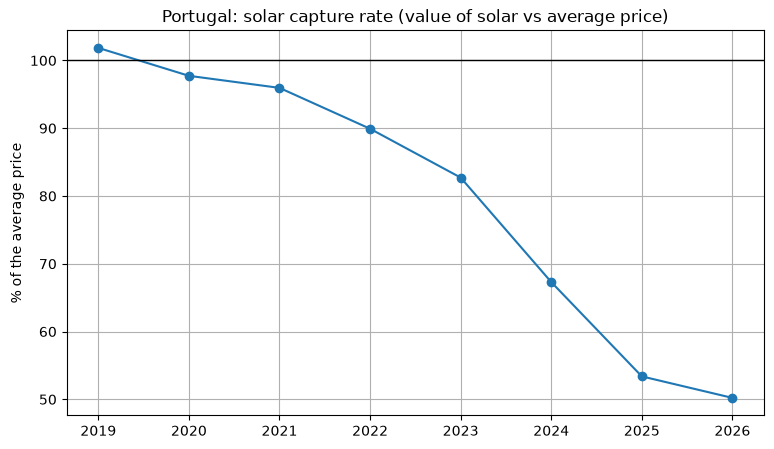

In [6]:
# Chart of the solar capture rate by year
plt.figure(figsize=(9, 5))
plt.plot(yearly.index, yearly["capture_rate"], marker="o")
plt.axhline(100, color="black", linewidth=1)
plt.title("Portugal: solar capture rate (value of solar vs average price)")
plt.ylabel("% of the average price")
plt.grid(True)
plt.savefig("../figures/solar_capture_rate.png")
plt.show()

## 4. Hours with zero or negative prices

In [7]:
# Number of hours per year with prices at or below 1 €/MWh, and below zero
near_zero = df[df["price_pt"] <= 1].groupby("year").size()
negative = df[df["price_pt"] < 0].groupby("year").size()
pd.DataFrame({"hours_at_or_below_1": near_zero, "hours_below_0": negative}).fillna(0).astype(int)

,hours_at_or_below_1,hours_below_0
year,,
2019,19,0
2021,52,0
2022,26,0
2023,124,0
2024,1033,196
2025,656,200
2026,1190,552


## 5. Regression: how much does each extra point of wind and solar lower the price?
Controlling for demand, hydro and the year (which captures the gas price level). HAC standard errors.

In [8]:
# Regression of the hourly price on wind and solar share, hydro share, demand and year
import statsmodels.formula.api as smf

df["hydro_share"] = df["hydro"] / df["consumption"] * 100
df["demand_gw"] = df["consumption"] / 1000

model = smf.ols("price_pt ~ renewable_share + hydro_share + demand_gw + C(year)", data=df).fit(cov_type="HAC", cov_kwds={"maxlags": 24})
print(model.summary().tables[1])
print("R-squared:", round(model.rsquared, 3), "| Observations:", int(model.nobs))

                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept          31.9329      3.455      9.242      0.000      25.161      38.705
C(year)[T.2020]   -12.6745      1.015    -12.482      0.000     -14.665     -10.684
C(year)[T.2021]    66.6580      3.847     17.329      0.000      59.119      74.197
C(year)[T.2022]   121.4498      3.170     38.316      0.000     115.237     127.662
C(year)[T.2023]    44.6483      1.502     29.733      0.000      41.705      47.591
C(year)[T.2024]    24.5248      1.955     12.543      0.000      20.693      28.357
C(year)[T.2025]    25.5130      1.702     14.989      0.000      22.177      28.849
C(year)[T.2026]    31.9001      2.835     11.253      0.000      26.344      37.456
renewable_share    -0.9371      0.037    -25.499      0.000      -1.009      -0.865
hydro_share        -0.1321      0.031     -4.332      0.000      -0.192     